# Setting up

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

mkdir -p failed for path /gpfs/home/yb2612/.config/matplotlib: [Errno 13] Permission denied: '/gpfs/home/yb2612/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-wscizq49 because there was an issue with the default path (/gpfs/home/yb2612/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
#---------------------------------
# PLOT CONFUSION MATRIX
#---------------------------------
def plot_confusion_matrix(col1, col2, title1, title2):
    
    # Create contingency table
    confusion = pd.crosstab(col1, col2)
    
    # Normalize by row to get relative proportions
    confusion_normalized = confusion.div(confusion.sum(axis=1), axis=0)
    
    # Plot heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(confusion_normalized, cmap="viridis", annot=True, fmt=".2f")
    plt.title(f"Confusion matrix: {title1} vs. {title2}")
    plt.xlabel(title2)
    plt.ylabel(title1)
    plt.tight_layout()
    plt.show()

samples = [
    "10103",
    "28873",
    "34933",
    "49411",
    "39367",
    "08153",
    "09002",
    "02433",
    "07688",
    "00438",
    "04738",
    "07291",
    "00862",
    "10285"
]


# Comparing results from wrong and fixed coordinates 

10103
✅ Matches: 16166
❌ Mismatches: 466
📊 Accuracy: 97.20%



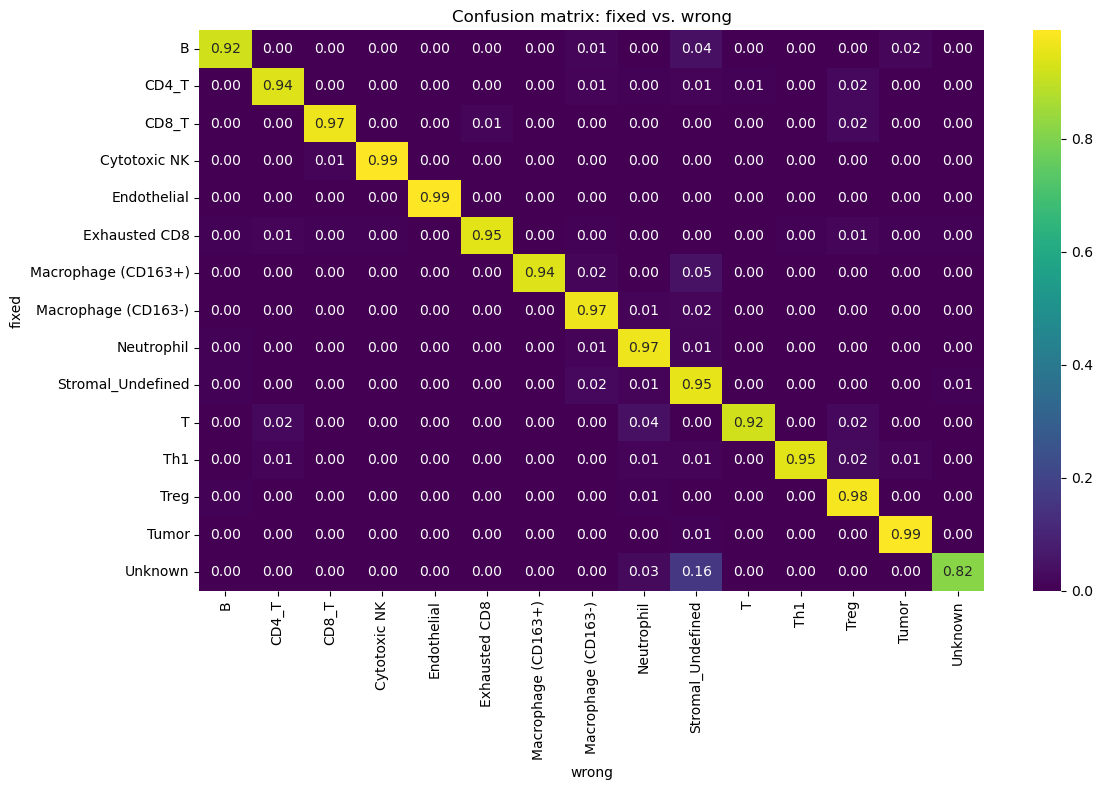

28873
✅ Matches: 25421
❌ Mismatches: 633
📊 Accuracy: 97.57%



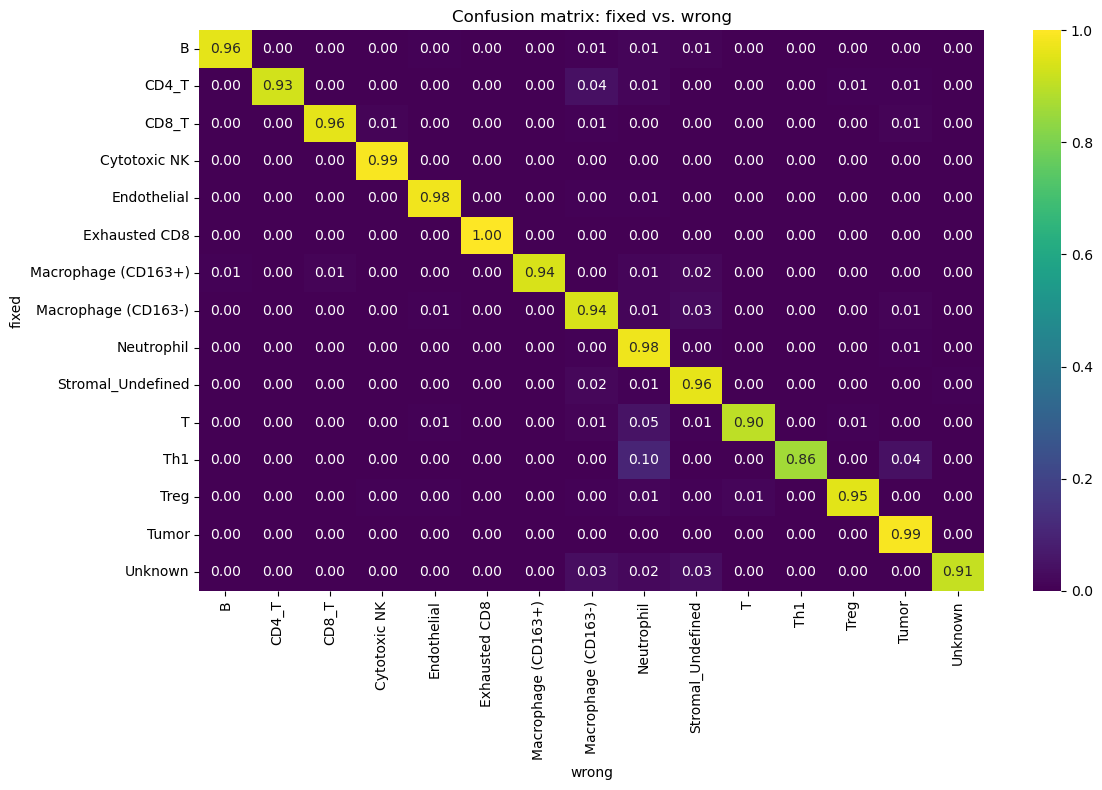

34933
✅ Matches: 34938
❌ Mismatches: 1264
📊 Accuracy: 96.51%



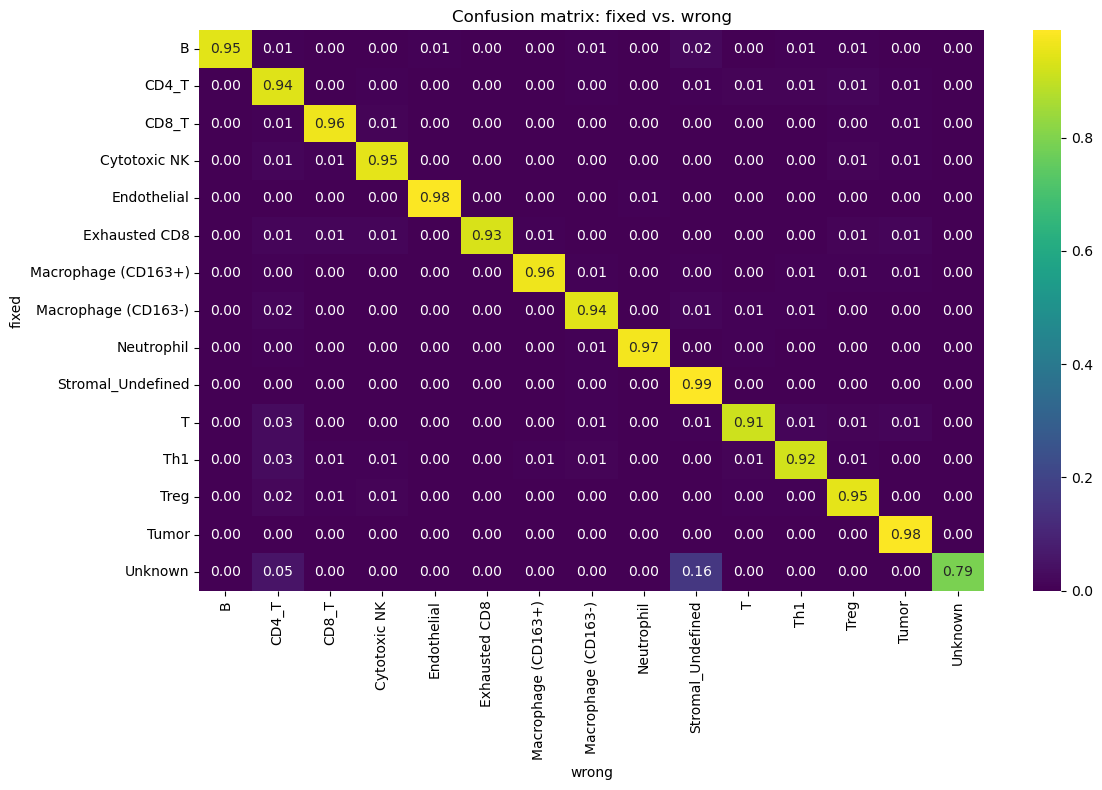

49411
✅ Matches: 49154
❌ Mismatches: 478
📊 Accuracy: 99.04%



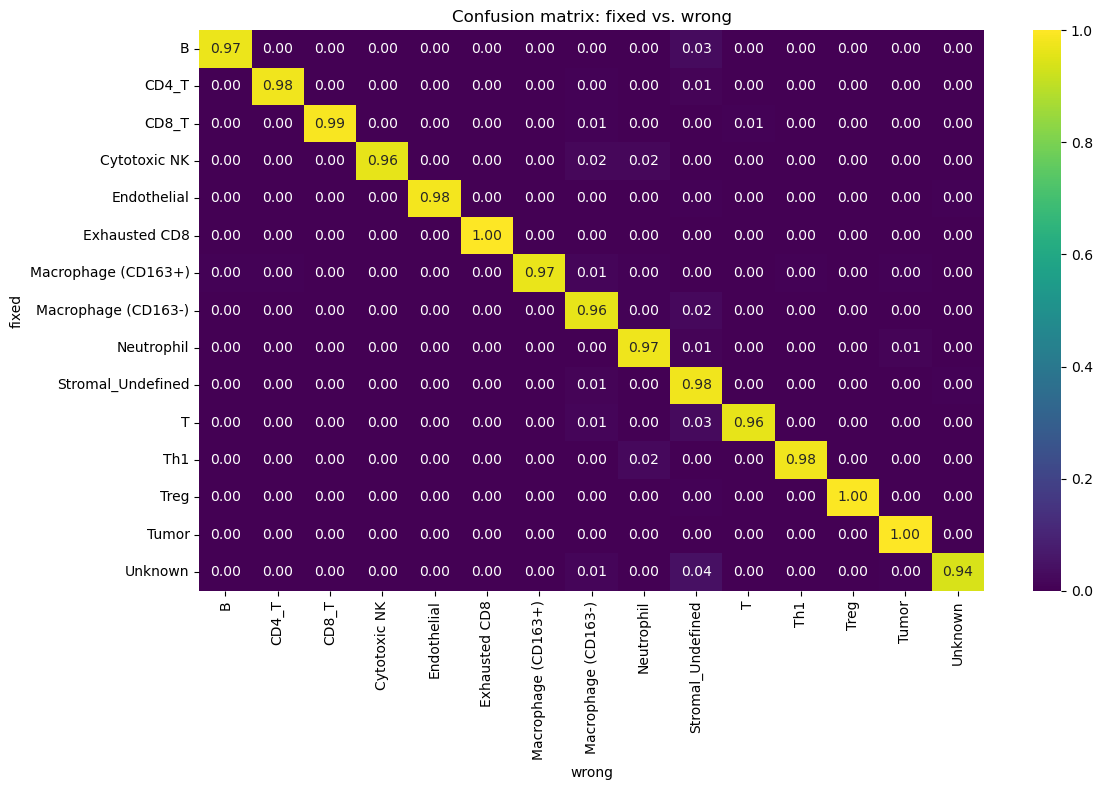

39367
✅ Matches: 84510
❌ Mismatches: 1750
📊 Accuracy: 97.97%



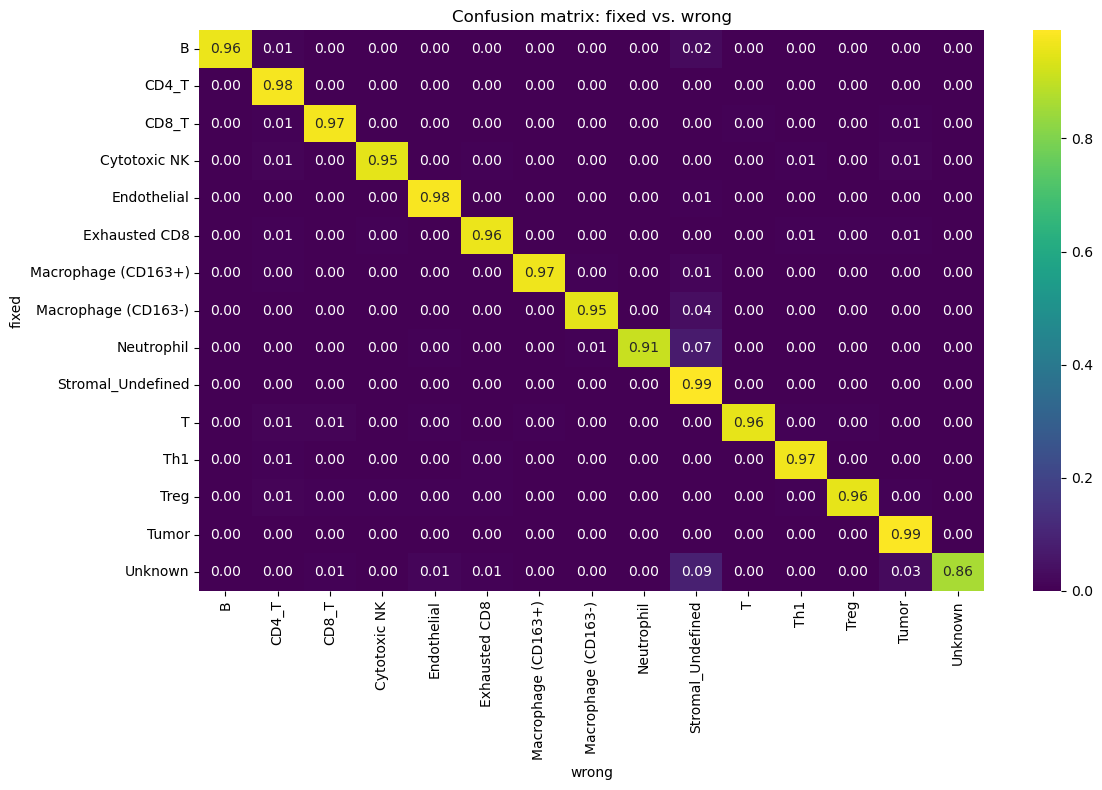

08153
✅ Matches: 101318
❌ Mismatches: 2302
📊 Accuracy: 97.78%



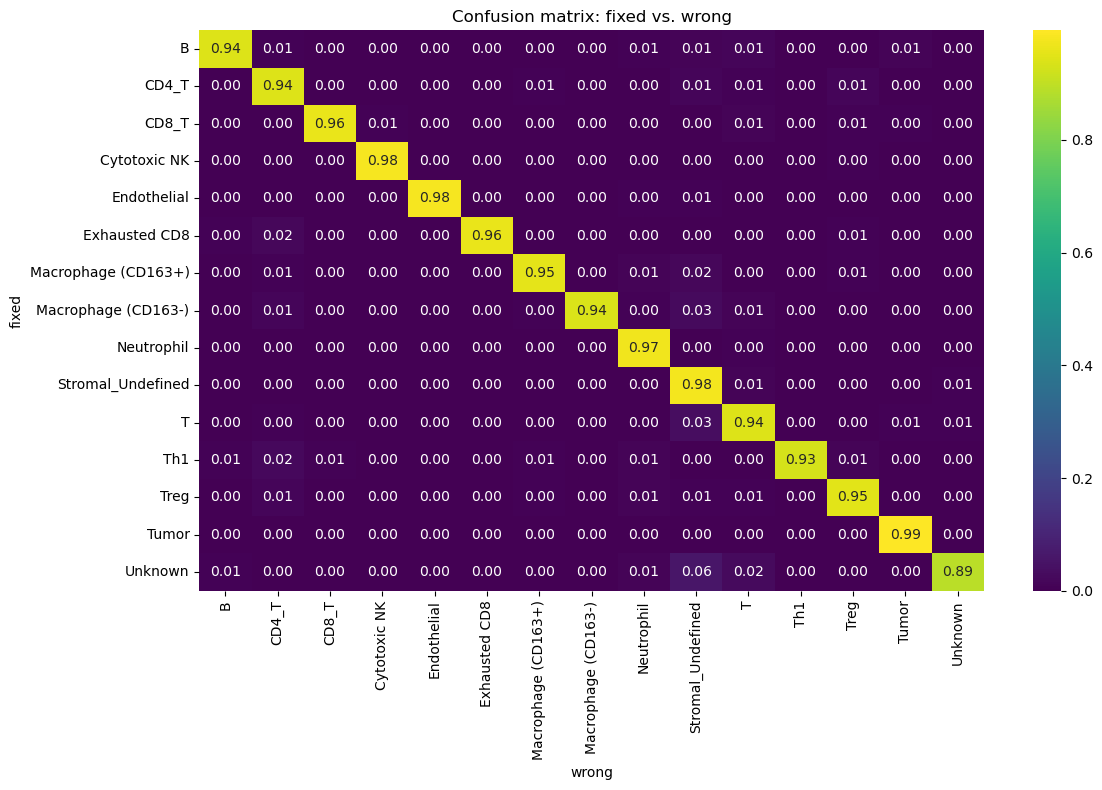

09002
✅ Matches: 191709
❌ Mismatches: 2636
📊 Accuracy: 98.64%



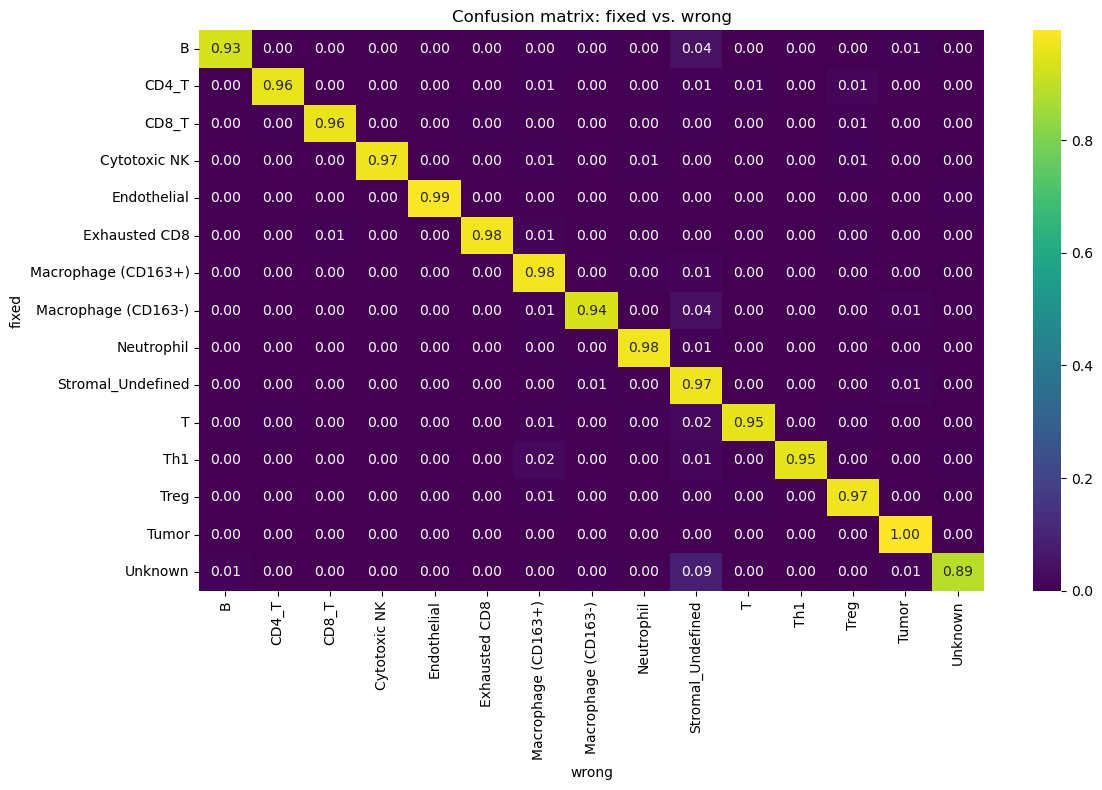

02433
✅ Matches: 192423
❌ Mismatches: 6125
📊 Accuracy: 96.92%



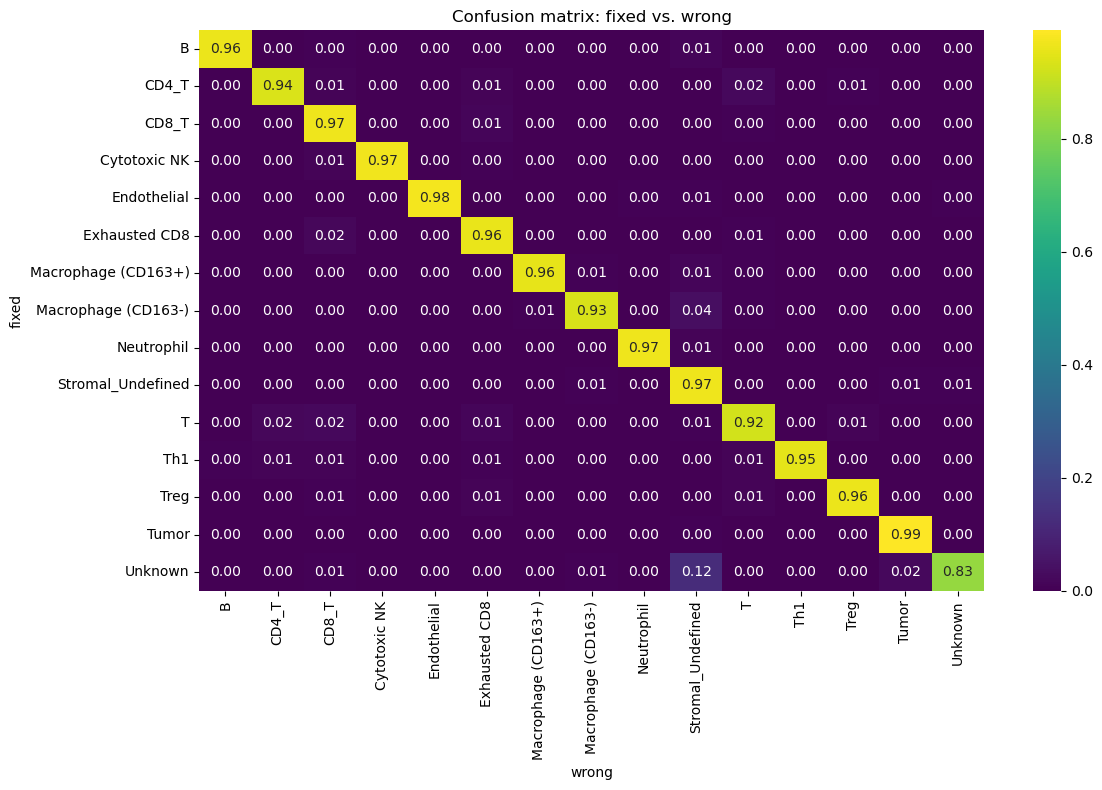

07688
✅ Matches: 213355
❌ Mismatches: 7991
📊 Accuracy: 96.39%



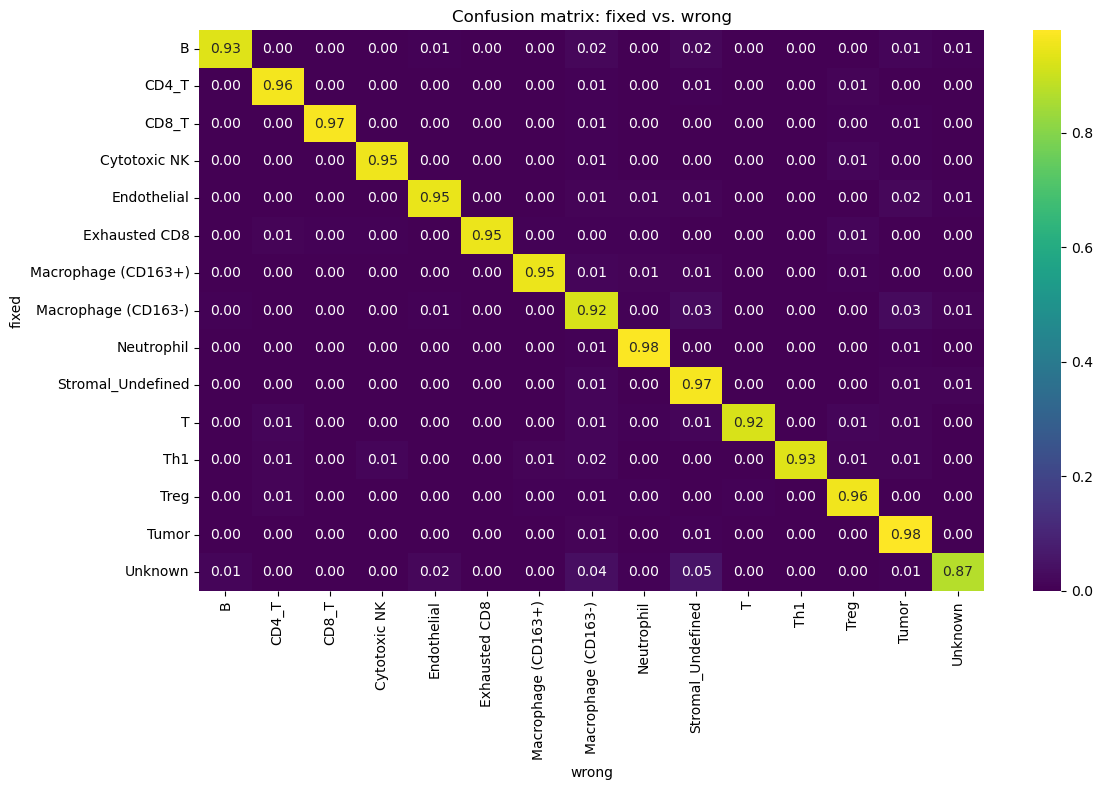

00438
✅ Matches: 260977
❌ Mismatches: 3996
📊 Accuracy: 98.49%



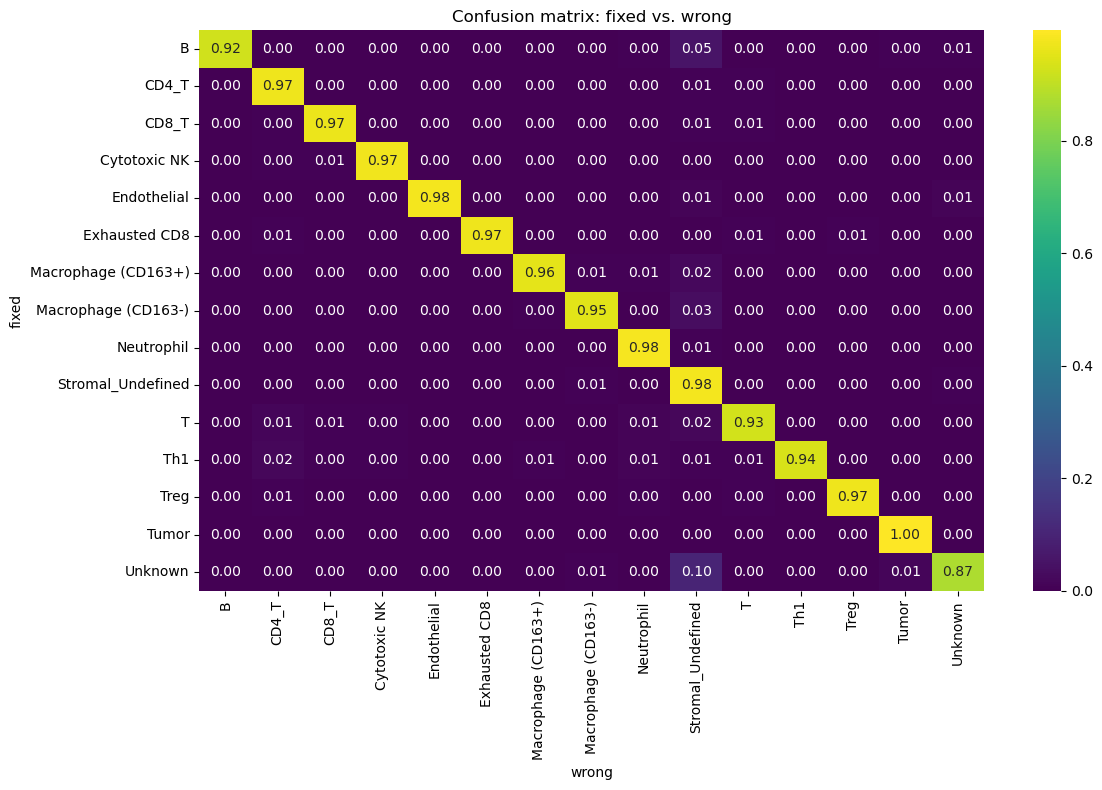

04738
✅ Matches: 397446
❌ Mismatches: 5384
📊 Accuracy: 98.66%



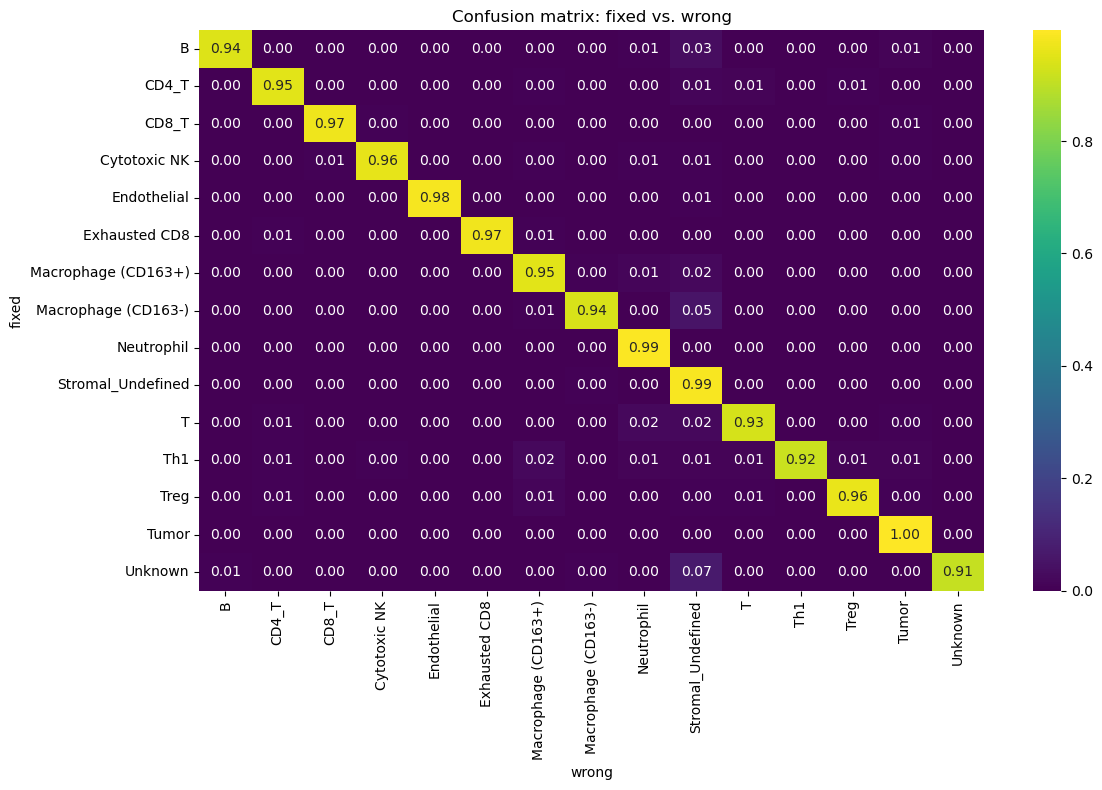

07291
✅ Matches: 1242904
❌ Mismatches: 28204
📊 Accuracy: 97.78%



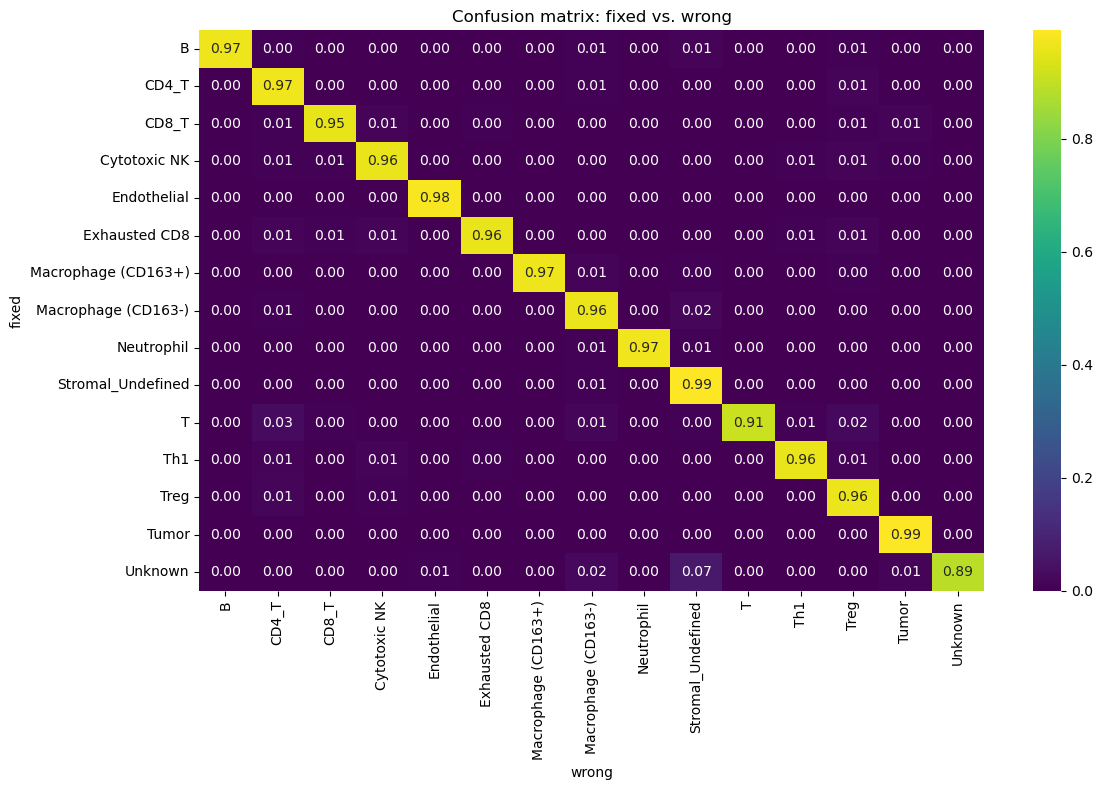

00862
[Errno 2] No such file or directory: '/gpfs/home/yb2612/yb2612_fenyo/results/celesta/detailed_cell_types/cervical_00862_raw_arcsinh/cervical_00862_raw_arcsinh_high_anchor_default_high_iter_default_final_cell_type_assignment.csv'
10285
[Errno 2] No such file or directory: '/gpfs/home/yb2612/yb2612_fenyo/results/celesta/detailed_cell_types/cervical_10285_raw_arcsinh/cervical_10285_raw_arcsinh_high_anchor_default_high_iter_default_final_cell_type_assignment.csv'


In [5]:
results_dir = "/gpfs/home/yb2612/yb2612_fenyo/results/celesta"
fixed_results = os.path.join(results_dir, "detailed_cell_types")
wrong_results = os.path.join(results_dir, "detailed_cell_types_WRONG_COORDS")
comparison_df = pd.DataFrame(columns=["sample", "total", "matches", "mismatches", "pct_accuracy"])

for sample in samples:
    print(sample)
    try: 
        fixed = pd.read_csv(os.path.join(fixed_results, f"cervical_{sample}_raw_arcsinh", f"cervical_{sample}_raw_arcsinh_high_anchor_default_high_iter_default_final_cell_type_assignment.csv"))
        wrong = pd.read_csv(os.path.join(wrong_results, f"cervical_{sample}_raw_arcsinh", f"cervical_{sample}_raw_arcsinh_high_anchor_default_high_iter_default_final_cell_type_assignment.csv"))
    
        # compare Final cell type cols
        comparison = fixed["Final cell type"] == wrong["Final cell type"]
        
        num_total = len(comparison)
        num_matches = comparison.sum()
        num_mismatches = num_total - num_matches
        accuracy = (num_matches / num_total) * 100 if num_total > 0 else 0

        comparison_df.loc[len(comparison_df)] = [sample, num_total, num_matches, num_mismatches, accuracy]
        
        print(f"✅ Matches: {num_matches}")
        print(f"❌ Mismatches: {num_mismatches}")
        print(f"📊 Accuracy: {accuracy:.2f}%")
        print()

        plot_confusion_matrix(fixed["Final cell type"], wrong["Final cell type"], "fixed", "wrong")

    except Exception as e:
        print(e)
        continue

In [6]:
comparison_df

,sample,total,matches,mismatches,pct_accuracy
0,10103,16632,16166,466,97.198172
1,28873,26054,25421,633,97.570431
2,34933,36202,34938,1264,96.508480
3,49411,49632,49154,478,99.036912
4,39367,86260,84510,1750,97.971250
5,08153,103620,101318,2302,97.778421
6,09002,194345,191709,2636,98.643649
7,02433,198548,192423,6125,96.915104
8,07688,221346,213355,7991,96.389815
9,00438,264973,260977,3996,98.491922


In [9]:
print("average accuracy:", np.mean(comparison_df["pct_accuracy"]))

average accuracy: 97.74572997725653
